Task1: Import Required Libraries


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
import geopandas as gpd
import folium

Task 2: Load Natural Earth Dataset Guide Questions
1. How many Columns does the dataset contain?
**The dataset contains multiple attribute columns (around 6–10 depending on version) including country information and one geometry column.**
2. What type of geometries are included
**The dataset mainly contains Polygon and MultiPolygon geometries representing country boundaries.**
3. What does the geometry column represent?
**The geometry column stores the spatial shape and boundary coordinates of each country.**


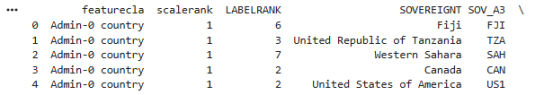

        featurecla  scalerank  LABELRANK                   SOVEREIGNT SOV_A3  \
0  Admin-0 country          1          6                         Fiji    FJI   
1  Admin-0 country          1          3  United Republic of Tanzania    TZA   
2  Admin-0 country          1          7               Western Sahara    SAH   
3  Admin-0 country          1          2                       Canada    CAN   
4  Admin-0 country          1          2     United States of America    US1   

   ADM0_DIF  LEVEL               TYPE TLC                        ADMIN  ...  \
0         0      2  Sovereign country   1                         Fiji  ...   
1         0      2  Sovereign country   1  United Republic of Tanzania  ...   
2         0      2      Indeterminate   1               Western Sahara  ...   
3         0      2  Sovereign country   1                       Canada  ...   
4         1      2            Country   1     United States of America  ...   

      FCLASS_TR     FCLASS_ID     FCLASS_PL 

<Axes: >

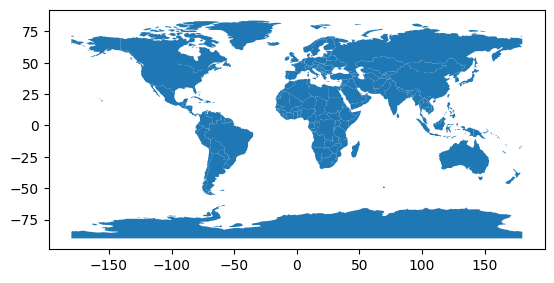

In [ ]:
url = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url)

print(world.head())
world.plot()

In [ ]:
print("Current CRS:", world.crs)

Current CRS: EPSG:4326


Task 3: Check the coordinate reference system
Guide Questions
1. What does EPSG:4326 represent?
**EPSG:4326 represents the WGS84 geographic coordinate system using latitude and longitude in degrees.**
2. Why is CRS important in spatial analysis
**CRS is important because it ensures spatial data aligns correctly and allows accurate distance and area calculations**

In [ ]:
world_projected = world.to_crs(epsg=3857)

world_projected["area_m2"] = world_projected.geometry.area

print(world_projected[["ADMIN", "area_m2"]].head())
print("\nArea Reprojection ✓ Complete")

                         ADMIN       area_m2
0                         Fiji  2.128334e+10
1  United Republic of Tanzania  9.522552e+11
2               Western Sahara  1.171023e+11
3                       Canada  5.216648e+13
4     United States of America  2.186228e+13

Area Reprojection ✓ Complete


Task 4: Convert to Metric CRS for Area Calculation
Guide Questions:
1. Why can't we compute area accurately using EPSG: 4326?
**Because EPSG:4326 uses degrees (latitude and longitude), not meters, so area calculations will not be accurate.**
2. What unit is EPSG: 3857 based on?
**EPSG:3857 is based on meters, making it suitable for measuring area and distance**
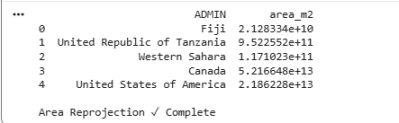

In [ ]:
world_projected["centroid"] = world_projected.geometry.centroid
world_projected["x"] = world_projected.centroid.x
world_projected["y"] = world_projected.centroid.y

print(world_projected[["ADMIN", "x", "y"]].head())


                         ADMIN             x             y
0                         Fiji  1.824878e+07 -1.958098e+06
1  United Republic of Tanzania  3.869296e+06 -7.003071e+05
2               Western Sahara -1.348403e+06  2.794163e+06
3                       Canada -1.079779e+07  1.044422e+07
4     United States of America -1.329713e+07  6.667416e+06


Task 5: Extract Centroid Coordinates
Guide Questions:


1.What is a centroid?
**A centroid is the geometric center point of a polygon.**
2.How can centroid coordinates be used in clustering?
**Centroid coordinates can represent each country as a single point, making them usable as numerical features for clustering algorithms.**
3. Why do we extract X and Y seperately?
**We extract X and Y separately because machine learning models require numerical feature columns instead of geometry objects**


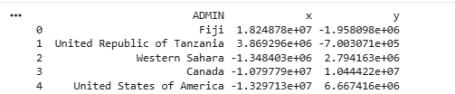

Reflection
1. What difficulties did you encounter?
**I encountered some difficulty understanding coordinate reference systems, especially why area calculations were incorrect in EPSG:4326 and required reprojection to a metric CRS.**
2. What did you learn about spatial data?
**I learned that spatial data depends heavily on the correct CRS, geometry types, and proper projection to ensure accurate analysis and meaningful results.**